# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [25]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [26]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

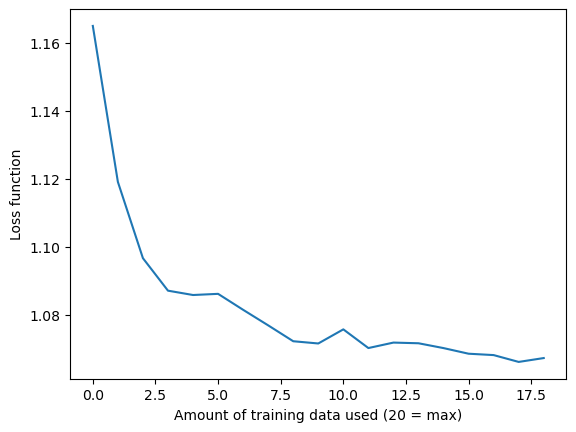

In [27]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [28]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

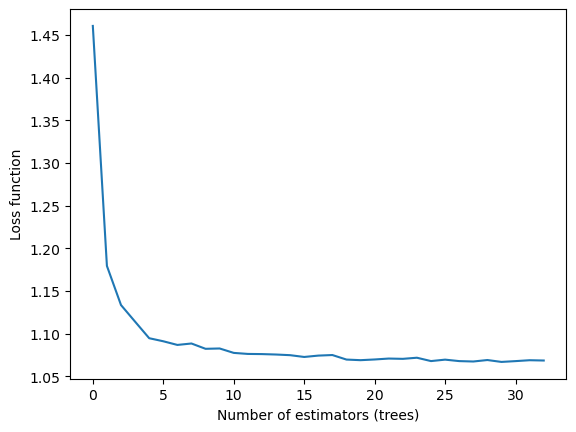

In [29]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

I would pick to keep the first plot, amount of training data used. The second graph is trivial in a business context. It's an interesting but purely methodological packet of information. I.e. it doesn't tell us anything about our data. The second plot could be about any model on any dataset. So to pick one, I would pick the first graph as it actually tells us something very interesting about the model's performance on our data. The more data that is used, the lower the loss function is. That is not the case with every dataset as some include more noise or irrelevant samples which can plateau or even hurt performance. Whereas the second plot is generalizable across datasets.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [30]:
# Load datasets

# Dataset 1: Breast Cancer Wisconsin (Diagnostic)
# Using sklearn's built-in dataset as a reliable fallback

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=['Diagnosis'])
df_breast_cancer = X.join(y)
print(df_breast_cancer.shape)
df_breast_cancer.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [31]:
# Dataset 2: Cancer Data Brazil

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "cancer_data_eng.csv"

# Load the latest version with Latin-1 encoding (common for Brazilian Portuguese data)
df_cancer_brazil = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "joaopedromedeiros/cancer-data-brazil",
  file_path,
  pandas_kwargs={"encoding": "latin-1"}  # Specify encoding for Portuguese characters
)

/var/folders/15/gy1f88h96yq8ylmls322kvxw0000gn/T/ipykernel_32235/3244826161.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_cancer_brazil = kagglehub.load_dataset(
/opt/anaconda3/lib/python3.13/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (3,5,6,7,8,9,10,13,14,23,24,25,27,28,29,30,31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(
/opt/anaconda3/lib/python3.13/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (3,5,6,7,8,9,10,13,14,23,24,25,27,28,29,30,31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [32]:
# Dataset 3: Heart Disease
# Using kagglehub to load the dataset

df_heart = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "johnsmith88/heart-disease-dataset",
    "heart.csv"
)
print(df_heart.shape)
df_heart.head()

/var/folders/15/gy1f88h96yq8ylmls322kvxw0000gn/T/ipykernel_32235/3940645923.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_heart = kagglehub.load_dataset(


(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [33]:
# Dataset 1 Analysis: Breast Cancer Wisconsin
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Prepare features and target
X_bc = df_breast_cancer.drop(columns=['Diagnosis'])
y_bc = df_breast_cancer['Diagnosis']

# Train/test split
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

# Fit a baseline random forest classifier
rf_bc = RandomForestClassifier(random_state=42)
rf_bc.fit(X_train_bc, y_train_bc)
y_pred_bc = rf_bc.predict(X_test_bc)
print("=== Dataset 1: Breast Cancer ===")
print(f"Baseline Accuracy: {accuracy_score(y_test_bc, y_pred_bc):.4f}")
print(classification_report(y_test_bc, y_pred_bc, target_names=['Malignant', 'Benign']))

# Hyperparameter tuning with RandomizedSearchCV
param_dist_bc = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_random_bc = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_bc,
    n_iter=20, cv=5, random_state=42, scoring='accuracy'
)
rf_random_bc.fit(X_train_bc, y_train_bc)

print(f"\nBest Parameters: {rf_random_bc.best_params_}")
print(f"Best CV Accuracy: {rf_random_bc.best_score_:.4f}")

# Evaluate tuned model on test set
y_pred_tuned_bc = rf_random_bc.predict(X_test_bc)
print(f"Tuned Test Accuracy: {accuracy_score(y_test_bc, y_pred_tuned_bc):.4f}")

=== Dataset 1: Breast Cancer ===
Baseline Accuracy: 0.9649
              precision    recall  f1-score   support

   Malignant       0.98      0.93      0.95        43
      Benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV Accuracy: 0.9670
Tuned Test Accuracy: 0.9737


In [34]:
# Explore Dataset 2 to find suitable target column
print("Shape:", df_cancer_brazil.shape)
print("\nColumn names:")
print(df_cancer_brazil.columns.tolist())
print("\nFirst few rows:")
df_cancer_brazil.head()

Shape: (1778176, 38)

Column names:
['Patient.Code', 'RCBP.Name', 'Gender', 'Date.of.Birth', 'Age', 'Raca.Color', 'Nationality', 'Naturality.State', 'Naturality', 'Degree.of.Education', 'State.Civil', 'Code.Profession', 'Name.Occupation', 'Status.Address', 'City.Address', 'Description.of.Topography', 'Topography.Code', 'Morphology.Description', 'Code.of.Morphology', 'Description.of.Disease', 'Illness.Code', 'Child.Illness.Description', 'Child.Illness.Code', 'Youth.Adult.Illness.Description', 'Code.of.Disease.Adult.Young.', 'Indicator.of.Rare.Case', 'Diagnostic.means', 'Extension', 'Laterality', 'Statement', 'TNM', 'Status.Vital', 'Type.of.Death', 'Date.of.Death', 'Date.of.Last.Contact', 'Date.of.Diagnostic', 'Distant.metastasis', 'year']

First few rows:


,Patient.Code,RCBP.Name,Gender,Date.of.Birth,Age,Raca.Color,Nationality,Naturality.State,Naturality,Degree.of.Education,...,Laterality,Statement,TNM,Status.Vital,Type.of.Death,Date.of.Death,Date.of.Last.Contact,Date.of.Diagnostic,Distant.metastasis,year
0,672054.0,RCBP CAMPINAS-UNICAMP,MASCULINO,1975-03-16,30.0,BRANCO,BRASIL,SÃO PAULO,NaN,NaN,...,NaN,NaN,NaN,MORTO,CÂNCER,2005-10-07,2005-10-07,2005-10-07,NaN,2005.0
1,673213.0,RCBP CAMPINAS-UNICAMP,FEMININO,1950-05-24,53.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,MORTO,NaN,2007-01-30,2007-01-30,2003-07-18,NaN,2003.0
2,673396.0,RCBP CAMPINAS-UNICAMP,FEMININO,1951-09-02,51.0,PARDA,BRASIL,SÃO PAULO,NaN,NaN,...,NaN,NaN,NaN,MORTO,CÂNCER,2005-07-03,2005-07-03,2003-05-16,NaN,2003.0
3,673425.0,RCBP CAMPINAS-UNICAMP,FEMININO,1929-11-21,73.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,VIVO,NaN,NaN,2010-07-28,2003-04-01,NaN,2003.0
4,673745.0,RCBP CAMPINAS-UNICAMP,MASCULINO,1934-07-03,71.0,BRANCO,BRASIL,SÃO PAULO,NaN,NaN,...,NaN,NaN,NaN,MORTO,CÂNCER,2005-10-21,2005-10-21,2005-10-21,NaN,2005.0


In [35]:
# Dataset 2 Analysis: Cancer Brazil
# Predict vital status (alive vs dead) from patient features

# Prepare data - select numeric/useful columns and encode target
df_brazil_clean = df_cancer_brazil[['Age', 'Gender', 'Status.Vital', 'Distant.metastasis', 'year']].copy()
df_brazil_clean = df_brazil_clean.dropna(subset=['Status.Vital', 'Age'])

# Encode target: VIVO=1 (alive), MORTO=0 (dead)
df_brazil_clean['target'] = (df_brazil_clean['Status.Vital'] == 'VIVO').astype(int)

# Encode Gender
df_brazil_clean['Gender_enc'] = (df_brazil_clean['Gender'] == 'MASCULINO').astype(int)

# Encode Distant metastasis
df_brazil_clean['Metastasis_enc'] = (df_brazil_clean['Distant.metastasis'] == 'SIM').astype(int)

# Fill remaining NaN and select features
df_brazil_clean['year'] = df_brazil_clean['year'].fillna(df_brazil_clean['year'].median())

X_br = df_brazil_clean[['Age', 'Gender_enc', 'Metastasis_enc', 'year']]
y_br = df_brazil_clean['target']

# Sample 10,000 rows to keep runtime reasonable
np.random.seed(42)
sample_idx = np.random.choice(len(X_br), size=min(10000, len(X_br)), replace=False)
X_br_sample = X_br.iloc[sample_idx]
y_br_sample = y_br.iloc[sample_idx]

# Train/test split
X_train_br, X_test_br, y_train_br, y_test_br = train_test_split(
    X_br_sample, y_br_sample, test_size=0.2, random_state=42
)

# Baseline random forest
rf_br = RandomForestClassifier(random_state=42)
rf_br.fit(X_train_br, y_train_br)
y_pred_br = rf_br.predict(X_test_br)
print("=== Dataset 2: Cancer Brazil ===")
print(f"Baseline Accuracy: {accuracy_score(y_test_br, y_pred_br):.4f}")
print(classification_report(y_test_br, y_pred_br, target_names=['Dead', 'Alive']))

# Hyperparameter tuning with RandomizedSearchCV
param_dist_br = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_random_br = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_br,
    n_iter=15, cv=5, random_state=42, scoring='accuracy'
)
rf_random_br.fit(X_train_br, y_train_br)

print(f"\nBest Parameters: {rf_random_br.best_params_}")
print(f"Best CV Accuracy: {rf_random_br.best_score_:.4f}")

y_pred_tuned_br = rf_random_br.predict(X_test_br)
print(f"Tuned Test Accuracy: {accuracy_score(y_test_br, y_pred_tuned_br):.4f}")

=== Dataset 2: Cancer Brazil ===
Baseline Accuracy: 0.6485
              precision    recall  f1-score   support

        Dead       0.70      0.71      0.71      1192
       Alive       0.57      0.56      0.56       808

    accuracy                           0.65      2000
   macro avg       0.63      0.63      0.63      2000
weighted avg       0.65      0.65      0.65      2000


Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5}
Best CV Accuracy: 0.6914
Tuned Test Accuracy: 0.6955


In [36]:
# Dataset 3 Analysis: Heart Disease
# Predict heart disease presence (target: 0 = no disease, 1 = disease)

X_hd = df_heart.drop(columns=['target'])
y_hd = df_heart['target']

# Train/test split
X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(X_hd, y_hd, test_size=0.2, random_state=42)

# Baseline random forest
rf_hd = RandomForestClassifier(random_state=42)
rf_hd.fit(X_train_hd, y_train_hd)
y_pred_hd = rf_hd.predict(X_test_hd)
print("=== Dataset 3: Heart Disease ===")
print(f"Baseline Accuracy: {accuracy_score(y_test_hd, y_pred_hd):.4f}")
print(classification_report(y_test_hd, y_pred_hd, target_names=['No Disease', 'Disease']))

# Hyperparameter tuning with RandomizedSearchCV
param_dist_hd = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_random_hd = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_hd,
    n_iter=20, cv=5, random_state=42, scoring='accuracy'
)
rf_random_hd.fit(X_train_hd, y_train_hd)

print(f"\nBest Parameters: {rf_random_hd.best_params_}")
print(f"Best CV Accuracy: {rf_random_hd.best_score_:.4f}")

y_pred_tuned_hd = rf_random_hd.predict(X_test_hd)
print(f"Tuned Test Accuracy: {accuracy_score(y_test_hd, y_pred_tuned_hd):.4f}")

=== Dataset 3: Heart Disease ===
Baseline Accuracy: 0.9854
              precision    recall  f1-score   support

  No Disease       0.97      1.00      0.99       102
     Disease       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV Accuracy: 0.9817
Tuned Test Accuracy: 1.0000


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.